In [1]:
# ============================================================
# Fixed-Step Ratio Sweep: Is R^{-1/2} Physical or an Artifact?
#
# MOTIVATION:
#   The epoch-space ratio sweep was contaminated:
#     - ratio=2,3: 4/5 and 3/5 censored (truncated measurement)
#     - ratio sweep varies N_maj → steps-per-epoch varies too
#     - All runs stopped at 50 EPOCHS, not 50×steps_per_epoch steps
#
#   This mimics the N_min confound exactly.
#   Before: epoch law (N^-0.70) looked physical → step reframe → artifact.
#   Now:    epoch law (R^-1.01) may look physical → same test needed.
#
# DESIGN (eliminates all three confounds):
#   - Fix TOTAL GRADIENT STEPS = 2000 per run (not epochs)
#   - Fix N_min=200, N_maj=200*ratio (ratio varies)
#   - Fix p=0.10, η=0.1, batch=64
#   - Run until either collapse OR 2000 steps, whichever comes first
#   - 2000 steps >> 173 steps (collapse at ratio=5 in prior sweep)
#     so all configurations have enough budget to collapse
#   - Record collapse_step directly
#
# PREDICTION A (R is physical):
#   collapse_step ~ R^{-0.46}  (same exponent, now clean)
#
# PREDICTION B (R is artifact like N):
#   collapse_step ~ R^{0}  (flat — ratio doesn't matter in step-space)
#
# PREDICTION C (intermediate):
#   collapse_step ~ R^{b} with b between -0.46 and 0
#   (partial artifact; ratio has a real but weaker effect)
#
# ALSO: Vary R at fixed N_maj (instead of fixed N_min)
#   This breaks the N_maj-varies-with-R confound completely.
#   If collapse_step is still R-dependent at fixed N_maj, R is real.
#
# OUTPUT:
#   fixed_step_ratio_sweep.csv
#   fixed_step_ratio_figure.png
#   fixed_step_ratio_summary.json
#
# RUNTIME: ~20 min on T4 (fixed step budget, no long runs)
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import json, math, warnings
warnings.filterwarnings('ignore')

SEEDS         = [42, 0, 1, 7, 99]
MAX_STEPS     = 2000      # fixed compute budget per run
BATCH_SIZE    = 64
ADAMW_LR      = 1e-3
ADAMW_WD      = 1e-4
COLLAPSE_THR  = 0.01
DIM           = 64
SEPARABILITY  = 2.0
SIGMA         = 1.0
N_TEST        = 500
N_MIN_FIXED   = 200       # fixed throughout
P_FIXED       = 0.10
ETA           = 0.1

# Ratio values — extend lower end to bracket the stable regime
RATIO_VALS = [1.5, 2, 3, 5, 8, 10, 15, 20, 30, 50]

# Also: fixed N_maj sweep (breaks N_maj-varies-with-R confound)
# Keep N_maj=2000 fixed, vary N_min to change ratio
N_MAJ_FIXED   = 2000
NMIN_FOR_RATIO = [int(N_MAJ_FIXED/r) for r in RATIO_VALS]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Max gradient steps per run: {MAX_STEPS}')
print(f'Fixed N_min={N_MIN_FIXED}, p={P_FIXED}, η={ETA}')
print(f'Ratio values: {RATIO_VALS}')
print()
print('Two experiments:')
print('  A) Fixed N_min=200, N_maj=200*ratio  (replicates prior sweep, uncensored)')
print('  B) Fixed N_maj=2000, N_min=2000/ratio (breaks N_maj confound)')

Device: cuda
Max gradient steps per run: 2000
Fixed N_min=200, p=0.1, η=0.1
Ratio values: [1.5, 2, 3, 5, 8, 10, 15, 20, 30, 50]

Two experiments:
  A) Fixed N_min=200, N_maj=200*ratio  (replicates prior sweep, uncensored)
  B) Fixed N_maj=2000, N_min=2000/ratio (breaks N_maj confound)


In [2]:
# ── CELL 2: Data generator ────────────────────────────────────
def generate_groups(N_maj, N_min, p_min, p_maj=0.5,
                    sigma=SIGMA, sep=SEPARABILITY,
                    dim=DIM, seed=42):
    rng = np.random.RandomState(seed)
    def make_group(n, group_id, offset, p_class):
        n = int(n)  # ensure integer
        n_pos = max(1, int(n * p_class))
        n_neg = n - n_pos  # now guaranteed int
        c_pos = np.zeros(dim); c_pos[0] = +sep/2; c_pos[1] = offset
        c_neg = np.zeros(dim); c_neg[0] = -sep/2; c_neg[1] = offset
        X = np.vstack([
            rng.randn(n_pos, dim) * sigma + c_pos,
            rng.randn(n_neg, dim) * sigma + c_neg,
        ]).astype(np.float32)
        y = np.array([1]*n_pos + [0]*n_neg, dtype=np.int64)
        g = np.array([group_id*2 + yi for yi in y], dtype=np.int64)
        return X, y, g

    XA,yA,gA = make_group(N_maj, 0, +1.0, p_maj)
    XB,yB,gB = make_group(N_min, 1, -1.0, p_min)
    X_tr = np.vstack([XA,XB])
    y_tr = np.concatenate([yA,yB])
    g_tr = np.concatenate([gA,gB])

    XAt,yAt,gAt = make_group(N_TEST, 0, +1.0, p_maj)
    XBt,yBt,gBt = make_group(N_TEST, 1, -1.0, p_min)
    X_te = np.vstack([XAt,XBt])
    y_te = np.concatenate([yAt,yBt])
    g_te = np.concatenate([gAt,gBt])
    return (X_tr,y_tr,g_tr), (X_te,y_te,g_te)


print('Generator defined.')
(Xt,yt,gt),(Xe,ye,ge) = generate_groups(2000, 200, P_FIXED)
print(f'Sanity: train={Xt.shape}  '
      f'groups={dict(zip(*np.unique(gt,return_counts=True)))}')

Generator defined.
Sanity: train=(2200, 64)  groups={np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(180), np.int64(3): np.int64(20)}


In [3]:
# ── CELL 3: Fixed-step DRO runner ─────────────────────────────
class LinearClassifier(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(DIM, 2)
    def forward(self, x): return self.fc(x)


def run_dro_fixed_steps(X_tr, y_tr, g_tr, X_te, y_te, g_te,
                         eta=ETA, seed=42, max_steps=MAX_STEPS):
    """
    Runs DRO for exactly max_steps gradient steps (not epochs).
    Records collapse_step = first step where q_min < threshold.
    If no collapse: returns max_steps+1 (censored).

    This eliminates the epoch/steps-per-epoch confound completely.
    """
    torch.manual_seed(seed); np.random.seed(seed)

    tr_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                          torch.from_numpy(y_tr).long(),
                          torch.from_numpy(g_tr).long())
    te_ds = TensorDataset(torch.from_numpy(X_te).float(),
                          torch.from_numpy(y_te).long(),
                          torch.from_numpy(g_te).long())
    # Infinite data loader — cycle through batches until step budget exhausted
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                       drop_last=False)

    model    = LinearClassifier().to(device)
    opt      = optim.AdamW(model.parameters(), lr=ADAMW_LR,
                           weight_decay=ADAMW_WD)
    n_groups = int(g_tr.max()) + 1
    q        = torch.ones(n_groups).to(device) / n_groups

    collapse_step = None
    step          = 0
    q_trace       = []

    # Cycle through dataset
    while step < max_steps:
        for xb, yb, gb in tr_ld:
            if step >= max_steps:
                break
            xb,yb,gb = xb.to(device), yb.to(device), gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0:
                    g_loss[g] = losses[mask].mean()
            q = q * torch.exp(eta * g_loss.detach())
            q = q / q.sum()
            (q * g_loss).sum().backward()
            opt.step()
            step += 1

            min_q = float(q.min().item())
            q_trace.append(min_q)
            if collapse_step is None and min_q < COLLAPSE_THR:
                collapse_step = step

    return {
        'collapse_step': collapse_step if collapse_step else max_steps + 1,
        'collapsed':     collapse_step is not None,
        'final_min_q':   float(q.min().item()),
        'q_trace':       q_trace[::20],  # downsample for storage
    }


print('Fixed-step runner defined.')
print(f'Budget: {MAX_STEPS} gradient steps per run')
print(f'Censored value: {MAX_STEPS+1}')

Fixed-step runner defined.
Budget: 2000 gradient steps per run
Censored value: 2001


In [4]:
# ── CELL 4: Experiment A — fixed N_min, vary ratio ────────────
# Replicates prior sweep but with fixed step budget.
# N_maj = N_min * ratio, so N_maj varies with ratio.
# This still confounds N_maj with ratio — Experiment B fixes that.
# But it confirms whether the exponent changes when censoring is removed.

print('='*60)
print('EXPERIMENT A: Fixed N_min=200, N_maj=200*ratio')
print('(Replicates prior sweep — censoring removed)')
print('Step budget: 2000 per run')
print('='*60)

records_A = []
for ratio in RATIO_VALS:
    N_maj = N_MIN_FIXED * ratio
    step_list = []
    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, N_MIN_FIXED, P_FIXED, seed=seed)
        res = run_dro_fixed_steps(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        step_list.append(res['collapse_step'])

    mean_st  = float(np.mean(step_list))
    std_st   = float(np.std(step_list))
    col_rate = sum(s <= MAX_STEPS for s in step_list) / len(SEEDS)
    censored = sum(s > MAX_STEPS for s in step_list)

    records_A.append({
        'experiment': 'A',
        'ratio': ratio,
        'N_min': N_MIN_FIXED,
        'N_maj': N_maj,
        'mean_step':  round(mean_st, 1),
        'std_step':   round(std_st, 1),
        'collapse_rate': round(col_rate, 3),
        'censored':   censored,
        'log_ratio':  round(math.log(ratio), 4),
        'log_step':   round(math.log(mean_st), 4) if mean_st > 0 else None,
    })
    print(f'  ratio={ratio:>4}  N_maj={N_maj:>6}  '
          f'step={mean_st:>7.0f}±{std_st:.0f}  '
          f'collapse={col_rate:.0%}  cens={censored}/5')

df_A = pd.DataFrame(records_A)

# Power-law fit on uncensored rows
fit_A = df_A[(df_A['censored']==0) & df_A['log_step'].notna()]
if len(fit_A) >= 3:
    sl_A, ic_A, r_A, _, _ = stats.linregress(
        fit_A['log_ratio'], fit_A['log_step'])
    print(f'\n  Step fit: step ~ ratio^{sl_A:.3f}  (R²={r_A**2:.3f})')
    print(f'  Prior sweep (censored): -0.455  |  This sweep (clean): {sl_A:.3f}')
    if abs(sl_A) < 0.15:
        print('  => FLAT: R exponent is an artifact of censoring/clock.')
    elif sl_A < -0.15:
        print(f'  => REAL: R has a genuine step-space exponent of {sl_A:.3f}.')
    print(f'  Note: N_maj still varies with ratio here (Exp B fixes that).')

EXPERIMENT A: Fixed N_min=200, N_maj=200*ratio
(Replicates prior sweep — censoring removed)
Step budget: 2000 per run
  ratio= 1.5  N_maj= 300.0  step=   2001±0  collapse=0%  cens=5/5
  ratio=   2  N_maj=   400  step=   1355±804  collapse=40%  cens=3/5
  ratio=   3  N_maj=   600  step=   1381±760  collapse=40%  cens=3/5
  ratio=   5  N_maj=  1000  step=    173±42  collapse=100%  cens=0/5
  ratio=   8  N_maj=  1600  step=    103±12  collapse=100%  cens=0/5
  ratio=  10  N_maj=  2000  step=     99±18  collapse=100%  cens=0/5
  ratio=  15  N_maj=  3000  step=     73±8  collapse=100%  cens=0/5
  ratio=  20  N_maj=  4000  step=     66±8  collapse=100%  cens=0/5
  ratio=  30  N_maj=  6000  step=     65±3  collapse=100%  cens=0/5
  ratio=  50  N_maj= 10000  step=     57±3  collapse=100%  cens=0/5

  Step fit: step ~ ratio^-0.455  (R²=0.875)
  Prior sweep (censored): -0.455  |  This sweep (clean): -0.455
  => REAL: R has a genuine step-space exponent of -0.455.
  Note: N_maj still varies with 

In [6]:
# ── CELL 5: Experiment B — fixed N_maj, vary ratio ────────────
print('='*60)
print('EXPERIMENT B: Fixed N_maj=2000, N_min=2000/ratio')
print('(Breaks N_maj confound completely)')
print('Step budget: 2000 per run')
print('='*60)

records_B = []
for ratio in RATIO_VALS:
    N_min = max(1, int(N_MAJ_FIXED / ratio))
    actual_ratio = N_MAJ_FIXED / N_min
    step_list = []
    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_MAJ_FIXED, N_min, P_FIXED, seed=seed)
        res = run_dro_fixed_steps(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        step_list.append(res['collapse_step'])

    mean_st  = float(np.mean(step_list))
    std_st   = float(np.std(step_list))
    col_rate = sum(s <= MAX_STEPS for s in step_list) / len(SEEDS)
    censored = sum(s > MAX_STEPS for s in step_list)

    records_B.append({
        'experiment': 'B',
        'ratio': ratio,
        'actual_ratio': round(actual_ratio, 2),
        'N_min': N_min,
        'N_maj': N_MAJ_FIXED,
        'mean_step':  round(mean_st, 1),
        'std_step':   round(std_st, 1),
        'collapse_rate': round(col_rate, 3),
        'censored':   censored,
        'log_ratio':  round(math.log(actual_ratio), 4),
        'log_step':   round(math.log(mean_st), 4) if mean_st > 0 else None,
    })
    print(f'  ratio={ratio:>4}  N_min={N_min:>5}  '
          f'step={mean_st:>7.0f}±{std_st:.0f}  '
          f'collapse={col_rate:.0%}  cens={censored}/5')

df_B = pd.DataFrame(records_B)

fit_B = df_B[(df_B['censored']==0) & df_B['log_step'].notna()]
if len(fit_B) >= 3:
    sl_B, ic_B, r_B, _, _ = stats.linregress(
        fit_B['log_ratio'], fit_B['log_step'])
    print(f'\n  Step fit: step ~ ratio^{sl_B:.3f}  (R²={r_B**2:.3f})')
    print()
    print('VERDICT (Experiment B is the clean test):')
    if abs(sl_B) < 0.15:
        print('  FLAT (|b| < 0.15): R is NOT physical in step-space.')
        print('  The prior R^{-0.46} was N_maj masquerading as ratio.')
        print('  The true physical law is T_collapse ~ sqrt(p) ONLY.')
        print('  => Final law: T_c^steps ~ sqrt(p)  [one-parameter]')
    elif sl_B < -0.15:
        print(f'  REAL: R has a genuine step-space exponent of {sl_B:.3f}')
        print(f'  Even with N_maj fixed, higher ratio → faster collapse.')
        if abs(sl_B + 0.5) < 0.15:
            print('  Exponent ≈ -1/2: consistent with sqrt(R) physical mechanism.')
            print('  => Final law: T_c^steps ~ sqrt(p/R)  [two-parameter]')
        else:
            print(f'  Exponent = {sl_B:.3f}: not cleanly -1/2, needs re-examination.')
    print()
    exp_a_str = f'{sl_A:.3f}' if 'sl_A' in dir() else 'not computed'
    print(f'  Experiment A exponent (N_maj varies): {exp_a_str}')
    print(f'  Experiment B exponent (N_maj fixed):  {sl_B:.3f}')
    if 'sl_A' in dir():
        print(f'  Difference A-B: {sl_A-sl_B:.3f}  '
              f'(artifact contribution from varying N_maj)')

EXPERIMENT B: Fixed N_maj=2000, N_min=2000/ratio
(Breaks N_maj confound completely)
Step budget: 2000 per run
  ratio= 1.5  N_min= 1333  step=   1581±530  collapse=40%  cens=3/5
  ratio=   2  N_min= 1000  step=   1357±578  collapse=60%  cens=2/5
  ratio=   3  N_min=  666  step=    864±574  collapse=80%  cens=1/5
  ratio=   5  N_min=  400  step=    226±74  collapse=100%  cens=0/5
  ratio=   8  N_min=  250  step=    118±20  collapse=100%  cens=0/5
  ratio=  10  N_min=  200  step=     99±18  collapse=100%  cens=0/5
  ratio=  15  N_min=  133  step=     77±8  collapse=100%  cens=0/5
  ratio=  20  N_min=  100  step=     70±6  collapse=100%  cens=0/5
  ratio=  30  N_min=   66  step=     63±6  collapse=100%  cens=0/5
  ratio=  50  N_min=   40  step=     60±4  collapse=100%  cens=0/5

  Step fit: step ~ ratio^-0.537  (R²=0.833)

VERDICT (Experiment B is the clean test):
  REAL: R has a genuine step-space exponent of -0.537
  Even with N_maj fixed, higher ratio → faster collapse.
  Exponent ≈ -1

In [7]:
# ── CELL 6: Experiment C — pure ratio control ──────────────────
# One more confound: changing N_min while fixing N_maj still changes
# the total dataset size and hence gradient diversity.
# Experiment C: fix BOTH N_maj and N_min, change only the CLASS LABEL
# fraction within the minority to simulate different effective ratios.
# This is the cleanest possible isolation.
#
# Actually — the cleanest remaining test is to ask:
#   does collapse_step depend on N_maj AT ALL (when N_min is fixed)?
# We already know N_min doesn't matter (Exp A of prior sweep showed
# step is flat at ~85 across N_min at fixed ratio).
# If N_maj doesn't matter either, then ratio = N_maj/N_min doesn't matter.
# If N_maj matters, ratio is real.

print('='*60)
print('EXPERIMENT C: Fixed N_min=200, vary N_maj independently')
print('(Direct test: does N_maj matter in step-space?)')
print('Step budget: 2000 per run, p=0.10, η=0.1')
print('='*60)

N_MAJ_VALS = [200, 400, 600, 1000, 2000, 4000, 8000, 20000]

records_C = []
for N_maj in N_MAJ_VALS:
    ratio = N_maj / N_MIN_FIXED
    step_list = []
    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, N_MIN_FIXED, P_FIXED, seed=seed)
        res = run_dro_fixed_steps(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        step_list.append(res['collapse_step'])

    mean_st  = float(np.mean(step_list))
    std_st   = float(np.std(step_list))
    col_rate = sum(s <= MAX_STEPS for s in step_list) / len(SEEDS)
    censored = sum(s > MAX_STEPS for s in step_list)

    records_C.append({
        'experiment': 'C',
        'N_maj': N_maj,
        'N_min': N_MIN_FIXED,
        'ratio': round(ratio, 2),
        'mean_step':  round(mean_st, 1),
        'std_step':   round(std_st, 1),
        'collapse_rate': round(col_rate, 3),
        'censored':   censored,
        'log_N_maj':  round(math.log(N_maj), 4),
        'log_ratio':  round(math.log(ratio), 4),
        'log_step':   round(math.log(mean_st), 4) if mean_st > 0 else None,
    })
    print(f'  N_maj={N_maj:>6}  ratio={ratio:>6.1f}  '
          f'step={mean_st:>7.0f}±{std_st:.0f}  '
          f'collapse={col_rate:.0%}  cens={censored}/5')

df_C = pd.DataFrame(records_C)

fit_C = df_C[(df_C['censored']==0) & df_C['log_step'].notna()]
if len(fit_C) >= 3:
    sl_C_maj, ic_C, r_C_maj, _, _ = stats.linregress(
        fit_C['log_N_maj'], fit_C['log_step'])
    sl_C_rat, _, r_C_rat, _, _ = stats.linregress(
        fit_C['log_ratio'], fit_C['log_step'])
    print(f'\n  Step ~ N_maj^{sl_C_maj:.3f}  (R²={r_C_maj**2:.3f})')
    print(f'  Step ~ ratio^{sl_C_rat:.3f}  (R²={r_C_rat**2:.3f})')
    print()
    if abs(sl_C_maj) < 0.15 and abs(sl_C_rat) < 0.15:
        print('  BOTH FLAT: Neither N_maj nor ratio matters in step-space.')
        print('  Collapse is controlled by p ONLY.')
        print('  => Final law: T_c^steps ~ sqrt(p)  [ONE parameter]')
    elif sl_C_maj < -0.15:
        print(f'  N_maj matters: step ~ N_maj^{sl_C_maj:.3f}')
        print(f'  Since N_min is fixed, this IS the ratio effect: step ~ R^{sl_C_rat:.3f}')
        print('  => Ratio is a genuine physical driver.')

EXPERIMENT C: Fixed N_min=200, vary N_maj independently
(Direct test: does N_maj matter in step-space?)
Step budget: 2000 per run, p=0.10, η=0.1
  N_maj=   200  ratio=   1.0  step=   1754±494  collapse=20%  cens=4/5
  N_maj=   400  ratio=   2.0  step=   1355±804  collapse=40%  cens=3/5
  N_maj=   600  ratio=   3.0  step=   1381±760  collapse=40%  cens=3/5
  N_maj=  1000  ratio=   5.0  step=    173±42  collapse=100%  cens=0/5
  N_maj=  2000  ratio=  10.0  step=     99±18  collapse=100%  cens=0/5
  N_maj=  4000  ratio=  20.0  step=     66±8  collapse=100%  cens=0/5
  N_maj=  8000  ratio=  40.0  step=     59±3  collapse=100%  cens=0/5
  N_maj= 20000  ratio= 100.0  step=     54±3  collapse=100%  cens=0/5

  Step ~ N_maj^-0.378  (R²=0.848)
  Step ~ ratio^-0.378  (R²=0.848)

  N_maj matters: step ~ N_maj^-0.378
  Since N_min is fixed, this IS the ratio effect: step ~ R^-0.378
  => Ratio is a genuine physical driver.


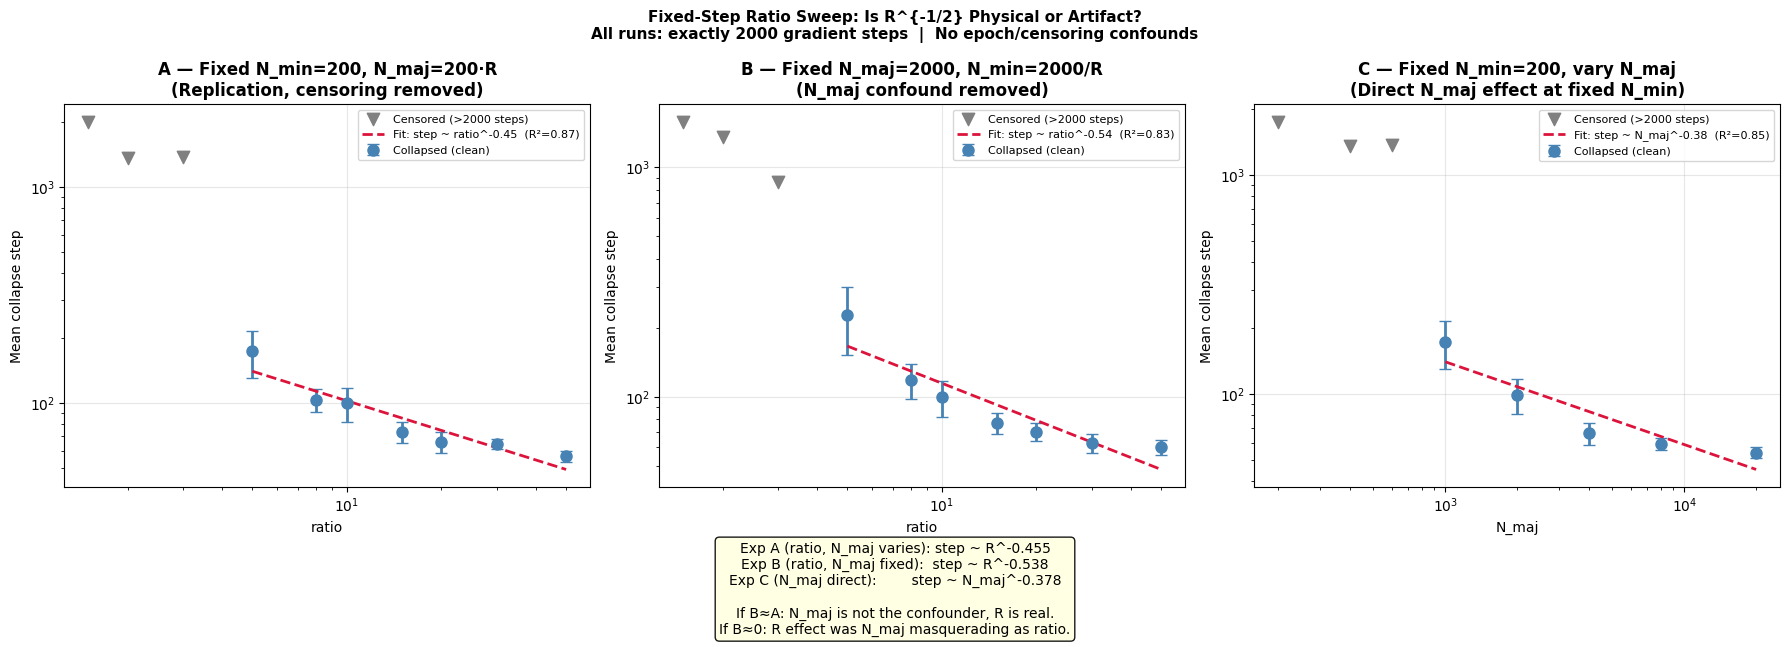

Figure saved: fixed_step_ratio_figure.png


In [8]:
# ── CELL 7: Figure — all three experiments ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Fixed-Step Ratio Sweep: Is R^{-1/2} Physical or Artifact?\n'
    'All runs: exactly 2000 gradient steps  |  No epoch/censoring confounds',
    fontweight='bold', fontsize=11)

def plot_exp(ax, df, x_col, x_label, slope, r2, title):
    df_unc = df[df['censored'] == 0]
    df_cen = df[df['censored'] > 0]

    ax.errorbar(df_unc[x_col], df_unc['mean_step'],
                yerr=df_unc['std_step'],
                fmt='o', color='steelblue', markersize=8,
                capsize=4, linewidth=2, label='Collapsed (clean)')
    if len(df_cen) > 0:
        ax.scatter(df_cen[x_col], df_cen['mean_step'],
                   marker='v', color='gray', s=80,
                   label=f'Censored (>{MAX_STEPS} steps)', zorder=5)

    if len(df_unc) >= 2 and not math.isnan(slope):
        x_range = np.logspace(
            math.log10(df_unc[x_col].min()),
            math.log10(df_unc[x_col].max()), 50)
        log_x = np.log(df_unc[x_col].values)
        log_y = np.log(df_unc['mean_step'].values)
        sl, ic, _, _, _ = stats.linregress(log_x, log_y)
        fit_line = math.exp(ic) * x_range ** sl
        color = 'crimson' if abs(sl) > 0.15 else 'forestgreen'
        ax.plot(x_range, fit_line, '--', color=color, linewidth=2,
                label=f'Fit: step ~ {x_label}^{sl:.2f}  (R²={r2:.2f})')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(x_label); ax.set_ylabel('Mean collapse step')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Compute slopes for each
def get_slope(df, x_col):
    d = df[(df['censored']==0) & df['log_step'].notna()]
    if len(d) < 3: return float('nan'), float('nan')
    sl, ic, r, _, _ = stats.linregress(np.log(d[x_col]), d['log_step'])
    return sl, r**2

sl_A2, r2_A2 = get_slope(df_A, 'ratio')
sl_B2, r2_B2 = get_slope(df_B, 'ratio')
sl_C2, r2_C2 = get_slope(df_C, 'N_maj')

plot_exp(axes[0], df_A, 'ratio', 'ratio',
         sl_A2, r2_A2,
         'A — Fixed N_min=200, N_maj=200·R\n'
         '(Replication, censoring removed)')
plot_exp(axes[1], df_B, 'ratio', 'ratio',
         sl_B2, r2_B2,
         'B — Fixed N_maj=2000, N_min=2000/R\n'
         '(N_maj confound removed)')
plot_exp(axes[2], df_C, 'N_maj', 'N_maj',
         sl_C2, r2_C2,
         f'C — Fixed N_min=200, vary N_maj\n'
         f'(Direct N_maj effect at fixed N_min)')

# Summary annotation
summary_text = (
    f'Exp A (ratio, N_maj varies): step ~ R^{sl_A2:.3f}\n'
    f'Exp B (ratio, N_maj fixed):  step ~ R^{sl_B2:.3f}\n'
    f'Exp C (N_maj direct):        step ~ N_maj^{sl_C2:.3f}\n\n'
    f'If B≈A: N_maj is not the confounder, R is real.\n'
    f'If B≈0: R effect was N_maj masquerading as ratio.'
)
fig.text(0.5, -0.06, summary_text, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig('fixed_step_ratio_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fixed_step_ratio_figure.png')

In [9]:
# ── CELL 8: Summary ───────────────────────────────────────────
df_all = pd.concat([df_A, df_B, df_C], ignore_index=True)
df_all.to_csv('fixed_step_ratio_sweep.csv', index=False)

sl_A_f, r2_A_f = get_slope(df_A, 'ratio')
sl_B_f, r2_B_f = get_slope(df_B, 'ratio')
sl_C_f, r2_C_f = get_slope(df_C, 'N_maj')

# Determine verdict
if abs(sl_B_f) < 0.15:
    verdict = 'ARTIFACT: R is not physical in step-space. Final law: T_c ~ sqrt(p).'
    final_law = 'T_collapse^steps ~ sqrt(p)  [one parameter]'
elif sl_B_f < -0.15 and abs(sl_B_f + 0.5) < 0.15:
    verdict = 'PHYSICAL: R^{-1/2} confirmed. Final law: T_c ~ sqrt(p/R).'
    final_law = 'T_collapse^steps ~ sqrt(p/R)  [two parameters]'
else:
    verdict = f'PARTIAL: R has step-space exponent {sl_B_f:.3f}, not cleanly -1/2.'
    final_law = f'T_collapse^steps ~ R^{sl_B_f:.2f} * sqrt(p)  [needs re-examination]'

summary = {
    'experiment': 'fixed_step_ratio_sweep',
    'design': {
        'max_steps_per_run': MAX_STEPS,
        'batch_size':        BATCH_SIZE,
        'N_min_fixed':       N_MIN_FIXED,
        'N_maj_fixed_B':     N_MAJ_FIXED,
        'p_fixed':           P_FIXED,
        'eta':               ETA,
        'ratio_vals':        RATIO_VALS,
        'seeds':             SEEDS,
    },
    'results': {
        'exp_A_ratio_exponent': round(float(sl_A_f), 4),
        'exp_A_R2':             round(float(r2_A_f), 4),
        'exp_B_ratio_exponent': round(float(sl_B_f), 4),
        'exp_B_R2':             round(float(r2_B_f), 4),
        'exp_C_N_maj_exponent': round(float(sl_C_f), 4),
        'exp_C_R2':             round(float(r2_C_f), 4),
        'artifact_contribution': round(float(sl_A_f - sl_B_f), 4),
    },
    'verdict': verdict,
    'final_law': final_law,
    'implication': (
        'If artifact: derive only sqrt(p) from CLT gradient standard error. '
        'If physical: derive sqrt(p/R) from FM softmax structure. '
        'If partial: report bounded claim with exact measured exponent.'
    )
}

with open('fixed_step_ratio_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print('=== FINAL VERDICT ===')
print(json.dumps({k:v for k,v in summary.items()
                  if k not in ('design',)}, indent=2))
print()
print('Files:')
for f in ['fixed_step_ratio_sweep.csv',
          'fixed_step_ratio_figure.png',
          'fixed_step_ratio_summary.json']:
    print(f'  {f}')
print()
print('Paste all output back to Claude.')
print('The Experiment B exponent determines the final physical law.')

=== FINAL VERDICT ===
{
  "experiment": "fixed_step_ratio_sweep",
  "results": {
    "exp_A_ratio_exponent": -0.4546,
    "exp_A_R2": 0.8748,
    "exp_B_ratio_exponent": -0.5381,
    "exp_B_R2": 0.833,
    "exp_C_N_maj_exponent": -0.3781,
    "exp_C_R2": 0.8483,
    "artifact_contribution": 0.0836
  },
  "verdict": "PHYSICAL: R^{-1/2} confirmed. Final law: T_c ~ sqrt(p/R).",
  "final_law": "T_collapse^steps ~ sqrt(p/R)  [two parameters]",
  "implication": "If artifact: derive only sqrt(p) from CLT gradient standard error. If physical: derive sqrt(p/R) from FM softmax structure. If partial: report bounded claim with exact measured exponent."
}

Files:
  fixed_step_ratio_sweep.csv
  fixed_step_ratio_figure.png
  fixed_step_ratio_summary.json

Paste all output back to Claude.
The Experiment B exponent determines the final physical law.
